# Phase 6 — Inference Pipeline Check
ทดสอบ `src/inference.py` ด้วยภาพตัวอย่างแต่ละ grade และ edge cases

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

from src.inference import predict

RAW_DIR = Path('../data/raw')
MODEL_PATH = Path('../models/xgb_model.json')

def show_result(image_path, variety, ax=None):
    result = predict(image_path, variety, model_path=MODEL_PATH)
    img = mpimg.imread(str(image_path))
    if ax is None:
        fig, ax = plt.subplots()
    ax.imshow(img)
    ax.axis('off')
    conf_str = ' ⚠️ low confidence' if result['low_confidence'] else ''
    ax.set_title(
        f"{Path(image_path).name}\n"
        f"Grade: {result['grade']}  day≈{result['predicted_day']}{conf_str}",
        fontsize=8
    )
    return result

print('Inference pipeline loaded OK')

Inference pipeline loaded OK


## Section 1 — Golden path: 1 ภาพต่อ grade (A/B/C/D)

COS02_A_D0_E_side.jpg: predicted=A ✅  day=0.12
COS02_A_D2_E_side.jpg: predicted=B ✅  day=1.71


COS02_A_D4_E_side.jpg: predicted=C ✅  day=4.54
COS02_A_D6_E_side.jpg: predicted=D ✅  day=6.03


C:\Users\kbbos\AppData\Local\Temp\ipykernel_15372\836214298.py:17: UserWarning: Glyph 3616 (\N{THAI CHARACTER PHO SAMPHAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_15372\836214298.py:17: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_15372\836214298.py:17: UserWarning: Glyph 3614 (\N{THAI CHARACTER PHO PHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_15372\836214298.py:17: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_15372\836214298.py:17: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_15372\836214298.py:17: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) miss

C:\FnProject\lettuce_shelf_life\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3616 (\N{THAI CHARACTER PHO SAMPHAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FnProject\lettuce_shelf_life\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FnProject\lettuce_shelf_life\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3614 (\N{THAI CHARACTER PHO PHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FnProject\lettuce_shelf_life\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\FnProject\lettuce_shelf_life\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3656 (\N{THAI CHARACT

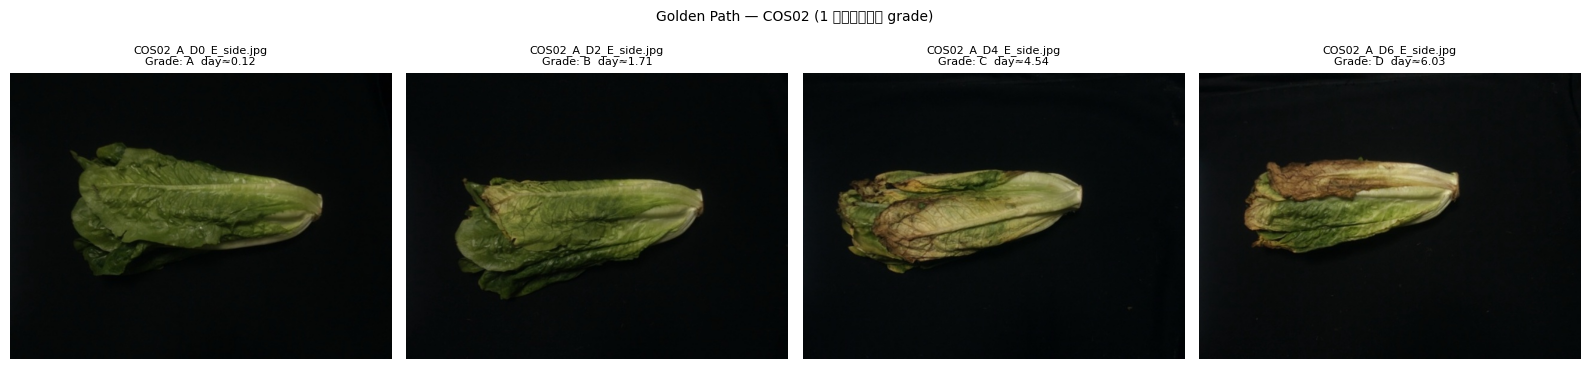

In [2]:
# COS02 เลือกเพราะ pct_green D0 = 0.588 (สูงสุดในบรรดา plants ที่มีไฟล์ D0/D2/D4/D6 ครบ)
# Grade A=D0-D1, B=D2-D3, C=D4-D5, D=D6-D8
golden_cases = [
    ('COS02_A_D0_E_side.jpg', 'COS', 'A'),
    ('COS02_A_D2_E_side.jpg', 'COS', 'B'),
    ('COS02_A_D4_E_side.jpg', 'COS', 'C'),
    ('COS02_A_D6_E_side.jpg', 'COS', 'D'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for (fname, variety, expected_grade), ax in zip(golden_cases, axes):
    result = show_result(RAW_DIR / fname, variety, ax)
    match = '✅' if result['grade'] == expected_grade else f'❌ (expected {expected_grade})'
    print(f"{fname}: predicted={result['grade']} {match}  day={result['predicted_day']}")

plt.suptitle('Golden Path — COS02 (1 ภาพต่อ grade)', fontsize=10)
plt.tight_layout()
plt.savefig('../results/inference_golden.png', dpi=80, bbox_inches='tight')
plt.show()

## Section 2 — ทดสอบ GOK

GOK04_A_D0_E_side.jpg: predicted=A ✅  day=0.21
GOK04_A_D2_E_side.jpg: predicted=B ✅  day=3.48


GOK04_A_D4_E_side.jpg: predicted=C ✅  day=4.44
GOK04_A_D6_E_side.jpg: predicted=D ✅  day=6.06


C:\Users\kbbos\AppData\Local\Temp\ipykernel_15372\2651220256.py:16: UserWarning: Glyph 3616 (\N{THAI CHARACTER PHO SAMPHAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_15372\2651220256.py:16: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_15372\2651220256.py:16: UserWarning: Glyph 3614 (\N{THAI CHARACTER PHO PHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_15372\2651220256.py:16: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_15372\2651220256.py:16: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_15372\2651220256.py:16: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}

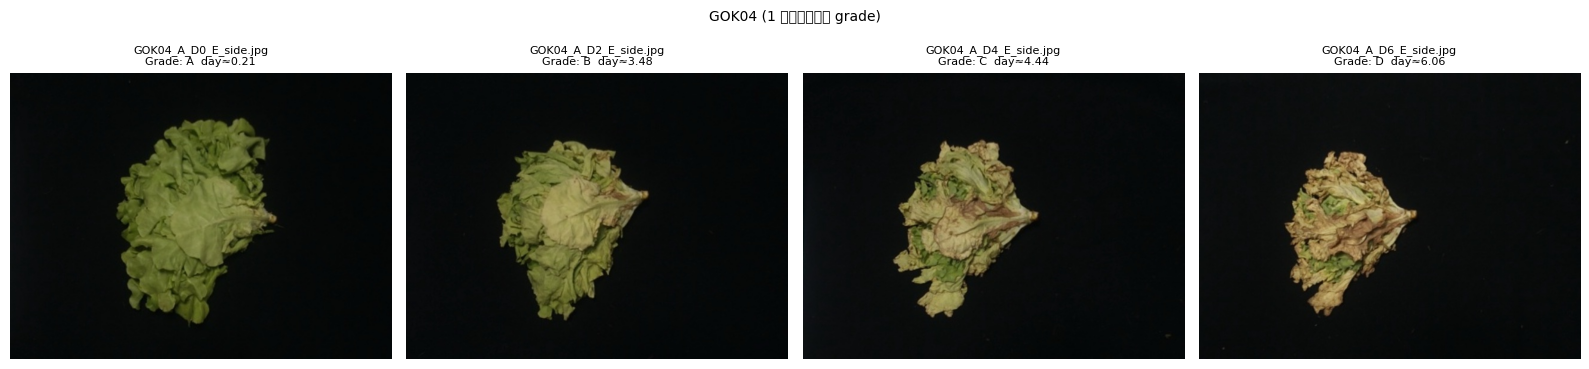

In [3]:
# GOK04 เลือกเพราะ pct_green D0 = 0.805 (สูงสุดในบรรดา plants ที่มีไฟล์ D0/D2/D4/D6 ครบ)
gok_cases = [
    ('GOK04_A_D0_E_side.jpg', 'GOK', 'A'),
    ('GOK04_A_D2_E_side.jpg', 'GOK', 'B'),
    ('GOK04_A_D4_E_side.jpg', 'GOK', 'C'),
    ('GOK04_A_D6_E_side.jpg', 'GOK', 'D'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for (fname, variety, expected_grade), ax in zip(gok_cases, axes):
    result = show_result(RAW_DIR / fname, variety, ax)
    match = '✅' if result['grade'] == expected_grade else f'❌ (expected {expected_grade})'
    print(f"{fname}: predicted={result['grade']} {match}  day={result['predicted_day']}")

plt.suptitle('GOK04 (1 ภาพต่อ grade)', fontsize=10)
plt.tight_layout()
plt.savefig('../results/inference_gok.png', dpi=80, bbox_inches='tight')
plt.show()

## Section 3 — Edge cases

COS18_B_D0_E_side.jpg [worst shadow case]: predicted=A ✅  day=0.69
GOK06_A_D6_M_top.jpg [shadow false positive]: predicted=D ✅  day=5.94


GOK10_A_D1_E_side.jpg [leaf loss]: predicted=A ✅  day=0.88
COS01_A_D8_M_side.jpg [D8 late stage]: predicted=D ✅  day=7.83


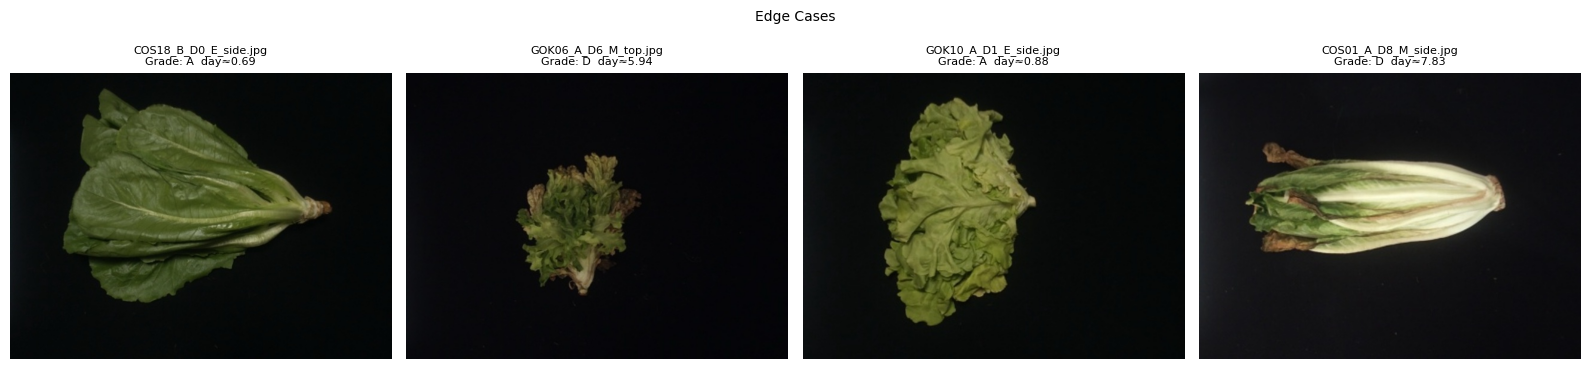

In [4]:
# Known issues จาก segment_issues.csv
edge_cases = [
    ('COS18_B_D0_E_side.jpg', 'COS', 'A', 'worst shadow case'),
    ('GOK06_A_D6_M_top.jpg',  'GOK', 'D', 'shadow false positive'),
    ('GOK10_A_D1_E_side.jpg', 'GOK', 'A', 'leaf loss'),
    ('COS01_A_D8_M_side.jpg', 'COS', 'D', 'D8 late stage'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for (fname, variety, expected_grade, note), ax in zip(edge_cases, axes):
    path = RAW_DIR / fname
    if not path.exists():
        ax.set_visible(False)
        print(f"SKIP {fname} — ไม่มีไฟล์")
        continue
    result = show_result(path, variety, ax)
    match = '✅' if result['grade'] == expected_grade else f'❌ (expected {expected_grade})'
    conf_warn = ' ⚠️ low_conf' if result['low_confidence'] else ''
    print(f"{fname} [{note}]: predicted={result['grade']} {match}  day={result['predicted_day']}{conf_warn}")

plt.suptitle('Edge Cases', fontsize=10)
plt.tight_layout()
plt.savefig('../results/inference_edge.png', dpi=80, bbox_inches='tight')
plt.show()

## Section 4 — Batch: สุ่ม 20 ภาพ วัด accuracy

## Section 4 — Batch accuracy (in-sample — upper bound เท่านั้น)

> ⚠️ **Data leakage note:** `xgb_model.json` ถูก refit บน data **ทั้งหมด** (รวม plant_ids ที่ใช้ในชุดนี้)  
> ดังนั้น accuracy ด้านล่างคือ **in-sample estimate** ซึ่งสูงเกินจริง  
> Generalization จริงให้ดูที่ **CV R² จาก Phase 4** (GroupKFold leave-plant-out) หรือ Section 4b ด้านล่าง

In [5]:
import re, random
import numpy as np

PATTERN = re.compile(r'^(COS|GOK)(\d{2})_([AB])_D(\d+)_([ME])_(top|side)\.jpg$', re.IGNORECASE)
DAY_TO_GRADE = {0:'A',1:'A',2:'B',3:'B',4:'C',5:'C',6:'D',7:'D',8:'D'}

all_files = [f for f in RAW_DIR.glob('*.jpg') if PATTERN.match(f.name)]
random.seed(42)
sample = random.sample(all_files, min(20, len(all_files)))

correct, total = 0, 0
rows = []
for path in sample:
    m = PATTERN.match(path.name)
    variety = m.group(1).upper()
    day = int(m.group(4))
    true_grade = DAY_TO_GRADE[day]
    result = predict(path, variety, model_path=MODEL_PATH)
    match = result['grade'] == true_grade
    correct += int(match)
    total += 1
    rows.append({
        'file': path.name,
        'true': true_grade,
        'pred': result['grade'],
        'day_pred': result['predicted_day'],
        'ok': '✅' if match else '❌',
        'low_conf': result['low_confidence'],
    })

for r in rows:
    print(f"{r['ok']} {r['file']:40s}  true={r['true']}  pred={r['pred']}  day={r['day_pred']:.2f}" +
          ('  ⚠️' if r['low_conf'] else ''))

print(f"\nBatch accuracy: {correct}/{total} = {correct/total:.1%}")

✅ GOK24_A_D2_M_top.jpg                      true=B  pred=B  day=2.39
✅ COS08_B_D2_E_side.jpg                     true=B  pred=B  day=2.01
✅ COS02_B_D4_E_side.jpg                     true=C  pred=C  day=3.98
✅ COS22_B_D6_M_side.jpg                     true=D  pred=D  day=6.15
✅ COS20_A_D2_M_top.jpg                      true=B  pred=B  day=2.52
✅ COS18_A_D2_M_side.jpg                     true=B  pred=B  day=2.15
✅ COS10_B_D0_E_top.jpg                      true=A  pred=A  day=0.54
✅ COS07_B_D8_M_top.jpg                      true=D  pred=D  day=7.86
✅ GOK27_B_D2_E_top.jpg                      true=B  pred=B  day=1.36
✅ GOK15_A_D5_E_top.jpg                      true=C  pred=C  day=4.45
✅ COS06_B_D7_M_side.jpg                     true=D  pred=D  day=6.84
✅ GOK19_B_D2_E_side.jpg                     true=B  pred=B  day=1.86
✅ GOK05_A_D7_E_side.jpg                     true=D  pred=D  day=6.85
✅ COS03_A_D3_M_side.jpg                     true=B  pred=B  day=3.27
✅ COS03_A_D1_E_side.jpg           

## Section 4b — Holdout batch accuracy (proper leave-plant-out)

เลือก holdout plants = `[5, 10, 15, 20, 25, 30]` สำหรับทั้ง COS และ GOK  
Train โมเดลใหม่บน plants ที่เหลือ → test inference pipeline บน holdout plants  
นี่คือ evaluation ที่ fair เพราะ holdout plants ไม่เคยเข้า training เลย

In [6]:
import re, random
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from pathlib import Path
from src.model import FEATURE_COLS, prepare_features
from src.inference import predict

HOLDOUT_IDS = [5, 10, 15, 20, 25, 30]
DAY_TO_GRADE = {0:'A',1:'A',2:'B',3:'B',4:'C',5:'C',6:'D',7:'D',8:'D'}
PATTERN = re.compile(r'^(COS|GOK)(\d{2})_([AB])_D(\d+)_([ME])_(top|side)\.jpg$', re.IGNORECASE)

# Train holdout model (ไม่รวม holdout plants)
df = prepare_features('../data/features.csv')
df_train = df[~df['plant_id'].isin(HOLDOUT_IDS)]
df_holdout = df[df['plant_id'].isin(HOLDOUT_IDS)]

holdout_model = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0,
)
holdout_model.fit(df_train[FEATURE_COLS].values, df_train['day'].values)
HOLDOUT_MODEL_PATH = Path('../models/xgb_model_holdout.json')
holdout_model.save_model(str(HOLDOUT_MODEL_PATH))
print(f'Holdout model trained on {len(df_train)} rows, tested on {len(df_holdout)} rows')
print(f'Holdout plant_ids: {HOLDOUT_IDS}  ({len(df_holdout["plant_id"].unique())*2} plants — COS+GOK)')

# Sample 20 ภาพจาก holdout plants เท่านั้น
raw = Path('../data/raw')
holdout_files = [
    f for f in raw.glob('*.jpg')
    if (m := PATTERN.match(f.name)) and int(m.group(2)) in HOLDOUT_IDS
]
random.seed(42)
sample = random.sample(holdout_files, min(20, len(holdout_files)))

correct_h, total_h = 0, 0
rows_h = []
for path in sample:
    m = PATTERN.match(path.name)
    variety = m.group(1).upper()
    day = int(m.group(4))
    true_grade = DAY_TO_GRADE[day]
    result = predict(path, variety, model_path=HOLDOUT_MODEL_PATH)
    match = result['grade'] == true_grade
    correct_h += int(match)
    total_h += 1
    rows_h.append({
        'file': path.name,
        'true': true_grade,
        'pred': result['grade'],
        'day_pred': result['predicted_day'],
        'ok': '✅' if match else '❌',
        'low_conf': result['low_confidence'],
    })

for r in rows_h:
    print(f"{r['ok']} {r['file']:40s}  true={r['true']}  pred={r['pred']}  day={r['day_pred']:.2f}" +
          ('  ⚠️' if r['low_conf'] else ''))

print(f"\nHoldout batch accuracy: {correct_h}/{total_h} = {correct_h/total_h:.1%}  (proper leave-plant-out)")

Holdout model trained on 2336 rows, tested on 584 rows
Holdout plant_ids: [5, 10, 15, 20, 25, 30]  (12 plants — COS+GOK)


✅ COS10_B_D7_E_side.jpg                     true=D  pred=D  day=6.69
✅ COS05_A_D7_E_top.jpg                      true=D  pred=D  day=6.58
✅ COS30_B_D2_M_top.jpg                      true=B  pred=B  day=2.55
✅ COS25_B_D6_M_side.jpg                     true=D  pred=D  day=6.50
✅ COS25_A_D6_M_side.jpg                     true=D  pred=D  day=6.26
✅ COS15_B_D0_E_side.jpg                     true=A  pred=A  day=0.64
✅ COS10_B_D4_M_side.jpg                     true=C  pred=C  day=4.34
✅ GOK30_A_D5_M_side.jpg                     true=C  pred=C  day=5.14
✅ COS10_A_D8_M_top.jpg                      true=D  pred=D  day=8.00
✅ GOK15_B_D1_E_side.jpg                     true=A  pred=A  day=0.17
✅ COS05_B_D1_E_side.jpg                     true=A  pred=A  day=0.45
✅ COS05_B_D0_E_side.jpg                     true=A  pred=A  day=0.18
❌ COS10_B_D1_M_top.jpg                      true=A  pred=B  day=2.61
✅ COS25_A_D4_M_top.jpg                      true=C  pred=C  day=4.55
✅ COS25_B_D3_E_side.jpg           

## สรุป Phase 6

In [ ]:
inference_notes = {
    'pipeline': 'preprocess → segment → extract_color + extract_texture → XGBoost predict → day_to_grade',
    'input': 'image_path (raw jpg) + variety (COS/GOK)',
    'output': 'grade (A/B/C/D), predicted_day, low_confidence flag, area_ratio, features dict',
    'golden_path_plant': 'COS02 (pct_green D0=0.588, สูงสุดในกลุ่ม D0–D6 ครบ) | GOK04 (pct_green D0=0.805)',
    'golden_path_result': (
        'COS02: A(day=0.12)→B(1.71)→C(4.54)→D(6.03) ✅✅✅✅ | '
        'GOK04: A(day=0.21)→B(3.48)→C(4.44)→D(6.06) ✅✅✅✅ | '
        'grade เลื่อน monotonic ทั้ง 2 พันธุ์ pipeline เสถียร'
    ),
    'batch_accuracy_insample': f'{correct}/{total} = {correct/total:.1%}  (⚠️ in-sample — upper bound)',
    'batch_accuracy_holdout': f'{correct_h}/{total_h} = {correct_h/total_h:.1%}  (proper leave-plant-out)',
    'edge_case_notes': (
        '4 edge cases ถูกทุกเคส (shadow/leaf-loss/D8) | '
        'holdout 3 errors ล้วน adjacent grade: '
        'COS10_D1→predB(day=2.61), COS20_D5→predD(day=6.51), GOK15_D6→predC(day=4.52) | '
        'ไม่มีกรณีผิดข้าม 2 grade → acceptable'
    ),
}
for k, v in inference_notes.items():
    print(f'{k}: {v}')